<a href="https://colab.research.google.com/github/Shashwat-006/Learning_PyTorch/blob/main/Learning_PyTorch_Basics_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AUTOGRAD**

In [1]:
import torch

In [2]:
x = torch.tensor(3.0, requires_grad = True)
#requires_grad is false by default & it tells the pytorch that we want to calculate derivative of this tensor
x

tensor(3., requires_grad=True)

## Example 1

In [3]:
y = x**2
y

tensor(9., grad_fn=<PowBackward0>)

In [4]:
y.backward() #calculates dy/dx

In [5]:
x.grad #gives y.backward @ value of x

tensor(6.)

## Example 2

In [6]:
x = torch.tensor(4.0, requires_grad = True)
y = x**2
y

tensor(16., grad_fn=<PowBackward0>)

In [7]:
z = torch.sin(y)
z

tensor(-0.2879, grad_fn=<SinBackward0>)

In [8]:
z.backward() #calculates dz/dx i.e., (dz/dy)*(dy/dx)

In [9]:
x.grad # y.grad can't be used cause grad function doesn't work on intermediate nodes!!

tensor(-7.6613)

input tensors are **LEAVES** and output tensors are **ROOT** and **backward** function does use chain rule from root to leaf

## Hypothetical Example of single neuron NN: 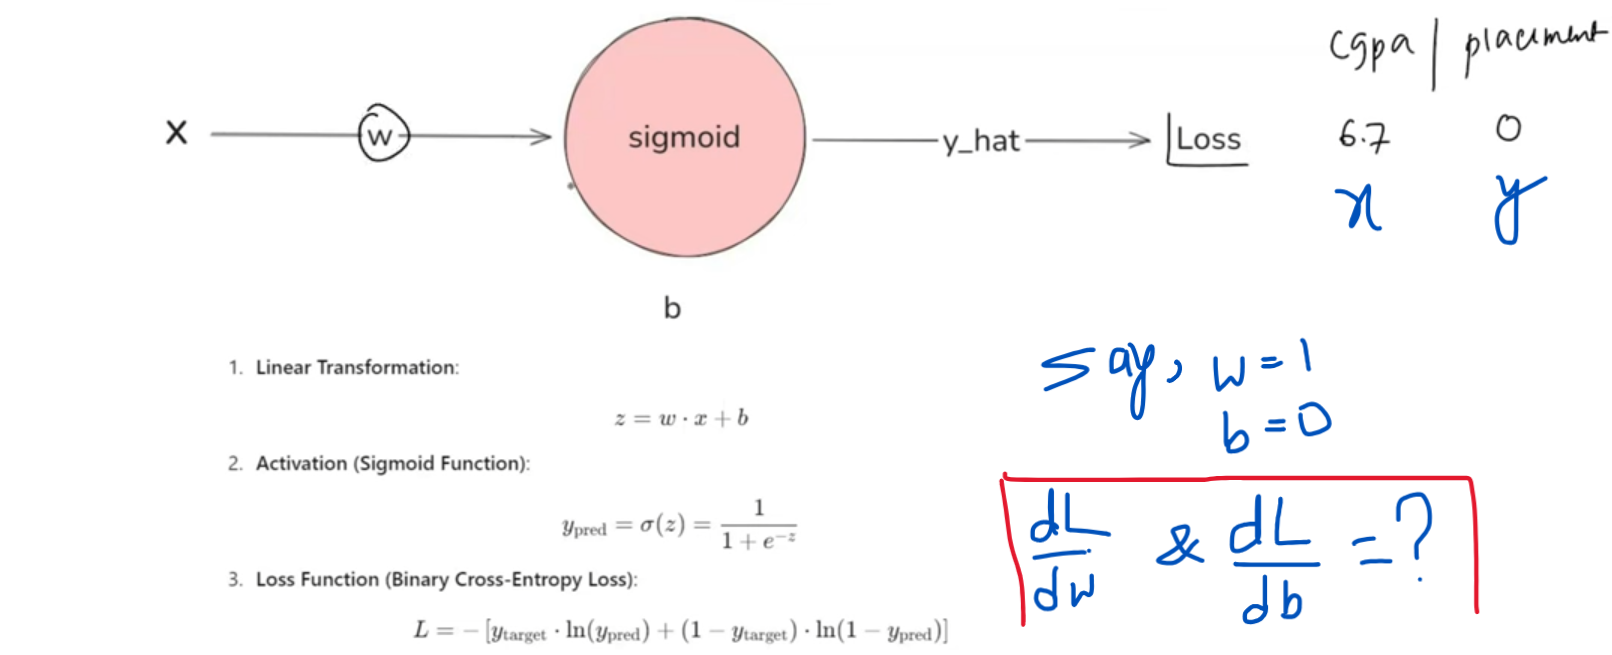

In [10]:
def binary_cross_entropy_loss(prediction, target):
  epsilon = 1e-8 #preventing log(0)
  prediction = torch.clamp(prediction, epsilon, 1-epsilon)
  return -(target* torch.log(prediction) + (1-target)*torch.log(1-prediction))

In [11]:
x = torch.tensor(6.7)
y = torch.tensor(0)

w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
b

tensor(0., requires_grad=True)

In [12]:
#Forward pass
z = w*x + b
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [13]:
y_pred = torch.sigmoid(z) #Predicted probability
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [14]:
#computing binary cross entropy loss
loss = binary_cross_entropy_loss(y_pred, y)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

In [15]:
loss.backward()

In [16]:
print(w.grad) #d(loss)/dw
print(b.grad) #d(loss)/db

tensor(6.6918)
tensor(0.9988)
